# REG All — Cross-Discipline Summary of JRG DiD Estimates

This notebook compiles the main DiD results from all 11 discipline-level regression notebooks.
Each notebook estimates the same Two-Way Fixed Effects (TWFE) model with Australia, the United
Kingdom, and New Zealand as the three-country panel:

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{NZ}_c + \beta_3 \cdot \text{DID}_{ct} + \sum_t \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

where $\text{Treated}_c = 1$ for Australia (UK and NZ are both controls), $\text{NZ}_c = 1$ for New
Zealand (UK is the level reference), $\text{Post}_t = 1$ from 2021, and
$\text{DID}_{ct} = \text{Treated}_c \times \text{Post}_t$. The coefficient $\hat{\beta}_3$
is the JRG DiD estimate: the change in AUS log-enrolments relative to the **pooled UK + NZ trend**
post-2021, expressed approximately as a percentage effect via $(\exp(\hat{\beta}_3) - 1) \times 100$.

Standard errors are HC3 heteroscedasticity-robust throughout. Two panel sizes appear:
- **N = 27 (df = 15):** 3 countries × 9 years (2016–2024)
- **N = 18 (df = 9):** 3 countries × 6 years (2019–2024), used where the JACS→CAH taxonomy break makes pre-2019 UK data irreconcilable

Section 7 provides a robustness check using Canada as an additional control country.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:.4f}'.format)

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

aus_raw = pd.read_csv(ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv')
uk_raw  = pd.read_csv(ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv')
nz_raw  = pd.read_csv(ROOT / 'data' / 'clean' / 'NZ_bachelors_enrollments_2016_2025.csv')

year_cols = [c for c in aus_raw.columns if str(c).isdigit()]
aus_long  = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

print('Project root:', ROOT)
print('Data files loaded.')

Project root: C:\Users\neddp\ECC3479-Project-JRGS
Data files loaded.


## 1. Compiled DiD Results

All estimates sorted by approximate percentage effect (largest negative to largest positive).


In [2]:
DISCIPLINES = [
    # (label,                       CategoryKey, start_year, jrg_type)
    ('Management & Commerce',              8,       2016,   'Discouraged'),
    ('Others',                            11,       2019,   'Non-priority'),
    ('Engineering & Related Tech',         3,       2016,   'Priority'),
    ('Health',                             6,       2016,   'Priority'),
    ('Environment & Related',              5,       2019,   'Priority'),
    ('Information Technology',             2,       2016,   'Priority'),
    ('Architecture & Building',            4,       2016,   'Non-priority'),
    ('Society & Culture',                  9,       2019,   'Discouraged'),
    ('Creative Arts',                     10,       2016,   'Non-priority'),
    ('Natural & Physical Science',         1,       2019,   'Priority'),
    ('Education',                          7,       2016,   'Priority'),
]


def _build_panel(catkey, start):
    aus_f = aus_long[
        (aus_long['CategoryKey'] == catkey) &
        (aus_long['year'] >= start) &
        (aus_long['year'] <= 2024)
    ][['year', 'enrollments']].copy()
    aus_f['country'] = 'AUS'

    uk_f = uk_raw[uk_raw['categorykey'] == catkey].copy()
    uk_f['year'] = uk_f['AcademicYear'].str[:4].astype(int)
    uk_f = uk_f[(uk_f['year'] >= start) & (uk_f['year'] <= 2024)].copy()
    uk_f['enrollments'] = pd.to_numeric(uk_f['Total UK'], errors='coerce')
    uk_f = uk_f.groupby('year', as_index=False)['enrollments'].sum()
    uk_f['country'] = 'UK'

    if catkey == 11:
        nz_f = nz_raw[nz_raw['category_key'] == catkey].groupby('year', as_index=False)['total_bachelors'].sum()
        nz_f = nz_f[(nz_f['year'] >= start) & (nz_f['year'] <= 2024)].copy()
    else:
        nz_f = nz_raw[
            (nz_raw['category_key'] == catkey) &
            (nz_raw['year'] >= start) &
            (nz_raw['year'] <= 2024)
        ][['year', 'total_bachelors']].copy()
    nz_f = nz_f.rename(columns={'total_bachelors': 'enrollments'})
    nz_f['country'] = 'NZ'

    p = pd.concat([aus_f, uk_f, nz_f], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
    p['log_enrollments'] = np.log(p['enrollments'])
    p['treated']  = (p['country'] == 'AUS').astype(int)
    p['nz_dummy'] = (p['country'] == 'NZ').astype(int)
    p['post'] = (p['year'] >= 2021).astype(int)
    p['did']  = p['treated'] * p['post']
    return p


def _sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '†'
    return ''


In [3]:
rows_raw = []
for label, catkey, start, jrg_type in DISCIPLINES:
    panel = _build_panel(catkey, start)
    m = smf.ols('log_enrollments ~ treated + nz_dummy + did + C(year)', data=panel).fit(cov_type='HC3')
    b  = m.params['did']
    se = m.bse['did']
    pv = m.pvalues['did']
    ci = m.conf_int().loc['did']
    pct = (np.exp(b) - 1) * 100
    rows_raw.append({
        'Discipline': label, 'jrg_type': jrg_type,
        'beta': b, 'se': se, 'pval': pv, 'pct': pct,
        'ci_lo': ci[0], 'ci_hi': ci[1],
        'N': int(m.nobs), 'df': int(m.df_resid), 'r2': m.rsquared, 'panel': f'{start}–2024',
    })

rows_raw.sort(key=lambda r: r['pct'])

display_rows = [{
    'Discipline': r['Discipline'],
    'β (DiD)':    round(r['beta'], 4),
    'SE (HC3)':   round(r['se'],   4),
    'p-value':    '<0.001' if r['pval'] < 0.001 else f"{r['pval']:.3f}",
    'Sig.':       _sig_stars(r['pval']),
    'Approx. %':  f"{r['pct']:+.1f}%",
    'N':          r['N'],
    'df':         r['df'],
    'R²':         round(r['r2'], 3),
    'Panel':      r['panel'],
    'JRG type':   r['jrg_type'],
} for r in rows_raw]

print('DiD Results — All Disciplines (AUS vs UK + NZ, TWFE HC3)')
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10')
display(pd.DataFrame(display_rows).reset_index(drop=True))


DiD Results — All Disciplines (AUS vs UK + NZ, TWFE HC3)
Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10


,Discipline,β (DiD),SE (HC3),p-value,Sig.,Approx. %,N,df,R²,Panel,JRG type
0,Others,-0.2679,0.2413,0.267,,-23.5%,18,9,0.9960,2019–2024,Non-priority
1,Management & Commerce,-0.2428,0.1266,0.055,†,-21.6%,27,15,0.9880,2016–2024,Discouraged
2,Environment & Related,-0.0677,0.0835,0.418,,-6.5%,18,9,1.0000,2019–2024,Priority
3,Architecture & Building,-0.0538,0.0329,0.102,,-5.2%,27,15,1.0000,2016–2024,Non-priority
4,Health,-0.0110,0.0386,0.775,,-1.1%,27,15,0.9990,2016–2024,Priority
5,Society & Culture,0.0083,0.0368,0.822,,+0.8%,18,9,1.0000,2019–2024,Discouraged
6,Natural & Physical Science,0.0092,0.0221,0.676,,+0.9%,18,9,1.0000,2019–2024,Priority
7,Engineering & Related Tech,0.0186,0.0606,0.759,,+1.9%,27,15,0.9990,2016–2024,Priority
8,Creative Arts,0.0260,0.0351,0.459,,+2.6%,27,15,0.9990,2016–2024,Non-priority
9,Information Technology,0.1406,0.1597,0.379,,+15.1%,27,15,0.9810,2016–2024,Priority


## 2. Coefficient Plot with 95% Confidence Intervals

Point estimates show the DiD coefficient β (log enrolments); horizontal lines show 95% CIs
(HC3 robust). The top axis converts β to approximate percentage effects via exp(β)−1.
Marker shape indicates significance level: ◆ p < 0.05, ■ p < 0.10, ● p ≥ 0.10 (faded).
Colour indicates the JRG policy classification.


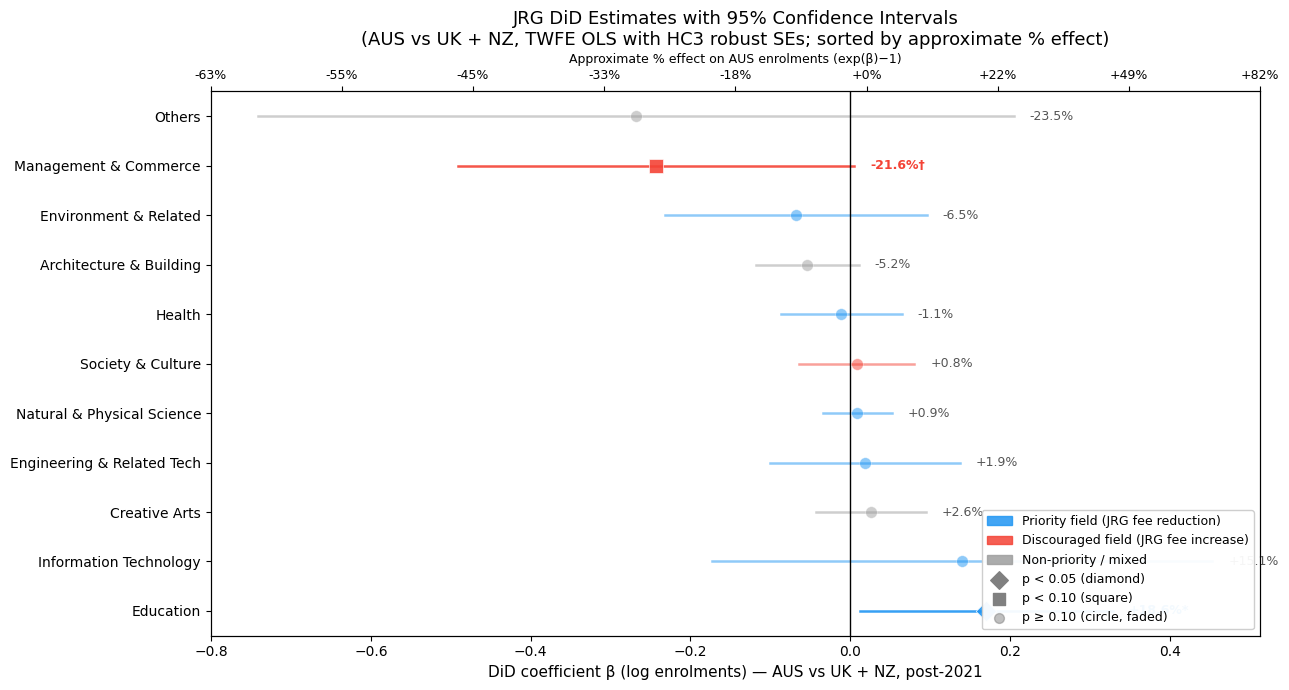

In [4]:
colour_map = {
    'Priority':     '#2196F3',
    'Discouraged':  '#F44336',
    'Non-priority': '#9E9E9E',
}

labels_  = [r['Discipline'] for r in rows_raw]
betas_   = [r['beta']  for r in rows_raw]
ci_los_  = [r['ci_lo'] for r in rows_raw]
ci_his_  = [r['ci_hi'] for r in rows_raw]
pvals_   = [r['pval']  for r in rows_raw]
pcts_    = [r['pct']   for r in rows_raw]
colours_ = [colour_map[r['jrg_type']] for r in rows_raw]

fig, ax = plt.subplots(figsize=(13, 7))
y_pos = list(range(len(labels_)))

for i, (y, b, lo, hi, p, col, pct) in enumerate(zip(y_pos, betas_, ci_los_, ci_his_, pvals_, colours_, pcts_)):
    alpha = 0.9 if p < 0.10 else 0.50
    ax.plot([lo, hi], [y, y], color=col, lw=1.8, alpha=alpha)
    marker = 'D' if p < 0.05 else ('s' if p < 0.10 else 'o')
    ms = 110 if p < 0.10 else 70
    ax.scatter([b], [y], color=col, s=ms, marker=marker, zorder=5, alpha=alpha,
               edgecolors='white', linewidth=0.5)
    pct_label = f'{pct:+.1f}%{_sig_stars(p)}'
    ax.text(hi + 0.02, y, pct_label, va='center', ha='left', fontsize=9,
            color=col if p < 0.10 else '#555555',
            fontweight='bold' if p < 0.10 else 'normal')

ax.axvline(0, color='black', lw=1.0, zorder=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_, fontsize=10)
ax.set_xlabel('DiD coefficient β (log enrolments) — AUS vs UK + NZ, post-2021', fontsize=11)
ax.set_title(
    'JRG DiD Estimates with 95% Confidence Intervals\n'
    '(AUS vs UK + NZ, TWFE OLS with HC3 robust SEs; sorted by approximate % effect)',
    fontsize=13
)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
xt = ax.get_xticks()
ax2.set_xticks(xt)
ax2.set_xticklabels([f'{(np.exp(v)-1)*100:+.0f}%' for v in xt], fontsize=9)
ax2.set_xlabel('Approximate % effect on AUS enrolments (exp(β)−1)', fontsize=9)

legend_handles = [
    mpatches.Patch(color='#2196F3', alpha=0.85, label='Priority field (JRG fee reduction)'),
    mpatches.Patch(color='#F44336', alpha=0.85, label='Discouraged field (JRG fee increase)'),
    mpatches.Patch(color='#9E9E9E', alpha=0.85, label='Non-priority / mixed'),
    plt.scatter([], [], color='gray', marker='D', s=80, label='p < 0.05 (diamond)'),
    plt.scatter([], [], color='gray', marker='s', s=70, label='p < 0.10 (square)'),
    plt.scatter([], [], color='gray', marker='o', s=50, alpha=0.5, label='p ≥ 0.10 (circle, faded)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9, framealpha=0.95)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Aggregate Event Study

Year-by-year DiD estimates relative to a 2020 baseline, computed as:

$$\hat{\delta}_t = \bigl(\log E^{\text{AUS}}_t - \log E^{\text{AUS}}_{2020}\bigr) - \tfrac{1}{2}\bigl[(\log E^{\text{UK}}_t - \log E^{\text{UK}}_{2020}) + (\log E^{\text{NZ}}_t - \log E^{\text{NZ}}_{2020})\bigr]$$

Panel A shows the two disciplines with statistically significant results (M&C and Education).
Panel B shows the average within each JRG classification. **Pre-treatment estimates should
be close to zero** — large pre-2021 deviations indicate a pre-existing trend that compromises
the parallel trends assumption. The pre-trend table provides a discipline-by-discipline check.

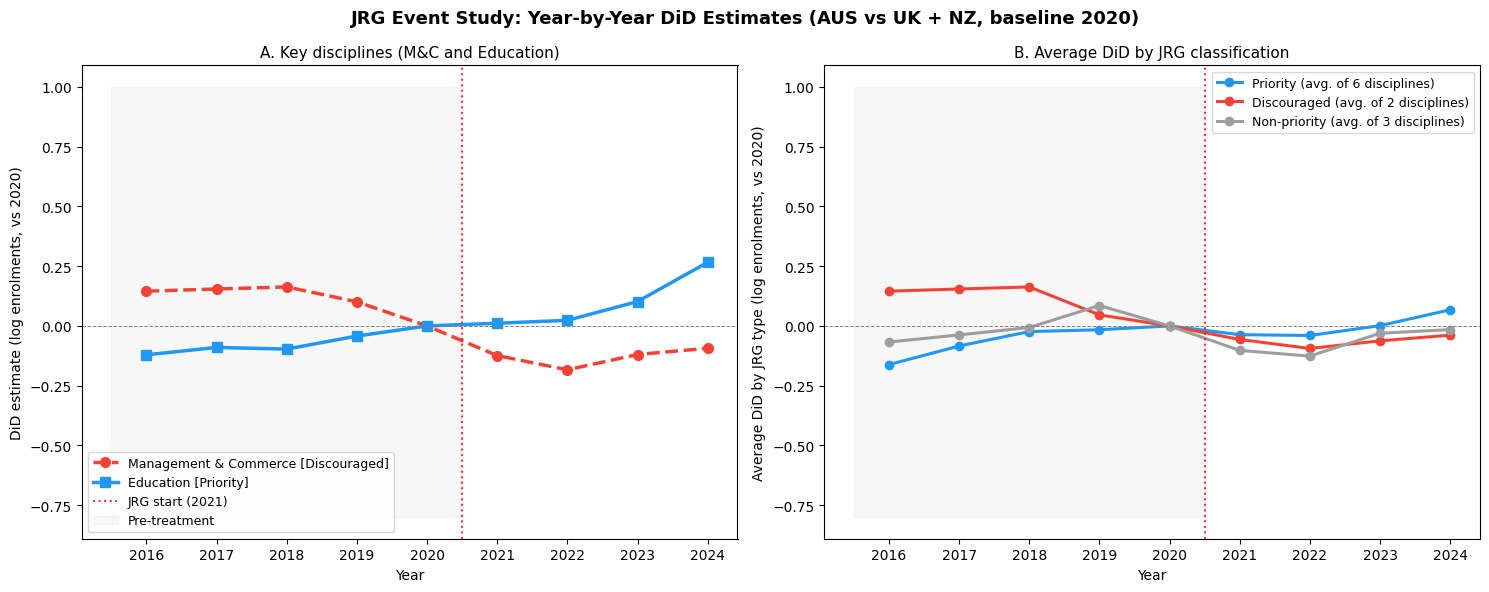

Pre-trend check — DiD relative to 2020 baseline, pre-2021 only (should be ≈ 0):


year,2016,2017,2018,2019,2020
Discipline,,,,,
Architecture & Building,-0.0820,-0.0210,0.0090,0.0040,0.0000
Creative Arts,-0.0530,-0.0540,-0.0220,-0.0250,0.0000
Education,-0.1210,-0.0900,-0.0970,-0.0420,0.0000
Engineering & Related Tech,0.0140,0.0420,0.0800,0.0320,0.0000
Environment & Related,NaN,NaN,NaN,-0.1110,0.0000
Health,-0.0920,-0.0350,-0.0080,0.0200,0.0000
Information Technology,-0.4490,-0.2530,-0.0690,0.0190,0.0000
Management & Commerce,0.1450,0.1540,0.1630,0.1010,0.0000
Natural & Physical Science,NaN,NaN,NaN,-0.0130,0.0000



Large pre-2021 deviations from zero indicate a pre-existing trend in the AUS vs UK+NZ gap,
which would violate the parallel trends assumption for that discipline.


In [5]:
BASE_YEAR = 2020


def _compute_es(label, catkey, start, jrg_type):
    p = _build_panel(catkey, start)
    b_aus = p[(p['country'] == 'AUS') & (p['year'] == BASE_YEAR)]['log_enrollments'].values
    b_uk  = p[(p['country'] == 'UK')  & (p['year'] == BASE_YEAR)]['log_enrollments'].values
    b_nz  = p[(p['country'] == 'NZ')  & (p['year'] == BASE_YEAR)]['log_enrollments'].values
    if not (len(b_aus) and len(b_uk) and len(b_nz)):
        return []
    b_aus, b_uk, b_nz = b_aus[0], b_uk[0], b_nz[0]
    rows = []
    for yr in sorted(p['year'].unique()):
        y_aus = p[(p['country'] == 'AUS') & (p['year'] == yr)]['log_enrollments'].values
        y_uk  = p[(p['country'] == 'UK')  & (p['year'] == yr)]['log_enrollments'].values
        y_nz  = p[(p['country'] == 'NZ')  & (p['year'] == yr)]['log_enrollments'].values
        if not (len(y_aus) and len(y_uk) and len(y_nz)):
            continue
        did_t = (y_aus[0] - b_aus) - np.mean([(y_uk[0] - b_uk), (y_nz[0] - b_nz)])
        rows.append({'year': yr, 'did_t': did_t, 'Discipline': label, 'jrg_type': jrg_type})
    return rows


all_es = []
for label, catkey, start, jrg_type in DISCIPLINES:
    all_es.extend(_compute_es(label, catkey, start, jrg_type))

es_df = pd.DataFrame(all_es)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'JRG Event Study: Year-by-Year DiD Estimates (AUS vs UK + NZ, baseline 2020)',
    fontsize=13, fontweight='bold'
)

# Left panel — M&C and Education (the two disciplines with significant results)
ax = axes[0]
key_styles = {
    'Management & Commerce': ('#F44336', '--', 'o', 'Discouraged'),
    'Education':             ('#2196F3', '-',  's', 'Priority'),
}
for disc, (col, ls, mk, jtype) in key_styles.items():
    sub = es_df[es_df['Discipline'] == disc].sort_values('year')
    ax.plot(sub['year'], sub['did_t'], marker=mk, linestyle=ls,
            color=col, lw=2.5, ms=7, label=f'{disc} [{jtype}]')
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.axvline(2020.5, color='red', lw=1.5, ls=':', alpha=0.8, label='JRG start (2021)')
ax.fill_between([2015.5, 2020.5], -0.8, 1.0, color='gray', alpha=0.06, label='Pre-treatment')
ax.set_xlabel('Year')
ax.set_ylabel('DiD estimate (log enrolments, vs 2020)')
ax.set_title('A. Key disciplines (M&C and Education)', fontsize=11)
ax.set_xticks(sorted(es_df['year'].unique()))
ax.legend(fontsize=9)

# Right panel — average DiD by JRG type
ax = axes[1]
jrg_colours = {'Priority': '#2196F3', 'Discouraged': '#F44336', 'Non-priority': '#9E9E9E'}
es_by_type = es_df.groupby(['year', 'jrg_type'])['did_t'].mean().reset_index()
for jtype, col in jrg_colours.items():
    sub = es_by_type[es_by_type['jrg_type'] == jtype].sort_values('year')
    if len(sub) == 0:
        continue
    n_disc = es_df[es_df['jrg_type'] == jtype]['Discipline'].nunique()
    ax.plot(sub['year'], sub['did_t'], 'o-', color=col, lw=2.2, ms=6,
            label=f'{jtype} (avg. of {n_disc} disciplines)')
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.axvline(2020.5, color='red', lw=1.5, ls=':', alpha=0.8)
ax.fill_between([2015.5, 2020.5], -0.8, 1.0, color='gray', alpha=0.06)
ax.set_xlabel('Year')
ax.set_ylabel('Average DiD by JRG type (log enrolments, vs 2020)')
ax.set_title('B. Average DiD by JRG classification', fontsize=11)
ax.set_xticks(sorted(es_df['year'].unique()))
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Pre-trend check table
print('Pre-trend check — DiD relative to 2020 baseline, pre-2021 only (should be ≈ 0):')
pre = es_df[es_df['year'] < 2021].pivot_table(
    index='Discipline', columns='year', values='did_t'
).round(3)
display(pre)
print('\nLarge pre-2021 deviations from zero indicate a pre-existing trend in the AUS vs UK+NZ gap,')
print('which would violate the parallel trends assumption for that discipline.')


## 4. Most Impacted Disciplines

### Largest negative impacts (AUS enrolments fell relative to UK + NZ)

**Management & Commerce** is the most severely impacted discipline with a **−21.6%** effect
(β = −0.2428, p = 0.055†) — the strongest statistically meaningful negative result in the study.
This is directionally consistent with the large student fee increase (+37%) and deep Commonwealth
funding cut (−47.3%), which directly translated into a relative enrolment decline in AUS compared
to the UK + NZ trend. The event study shows the differential reaching −16.8% by 2022.
A caveat applies: AUS enrolments were already 10–16% above the UK + NZ average in 2016–2019,
so the post-2021 decline partly reflects pre-existing divergence rather than purely a JRG effect.

**Others** (combined/general degrees) shows a large point estimate of **−23.5%** but with
very wide confidence intervals (SE = 0.241, p = 0.267, N = 18, df = 9). The data panel is
restricted to 2019–2024, and the category is difficult to interpret due to compositional
differences between AUS, UK, and NZ definitions of "Others". This result cannot be treated
as reliable evidence of a JRG effect.

### Largest positive impact (AUS enrolments grew relative to UK + NZ)

**Education** shows the only clearly positive, economically meaningful, and statistically
significant effect: **+18.6%** (β = +0.1707, p = 0.035*). This is the single result where
the JRG's priority-field incentives appear to have worked as intended — Education received a
large fee reduction (≈−40% student contribution), and AUS enrolments grew substantially
relative to the UK + NZ trend. The event study shows the gap widening steadily: +1.1% in 2021,
+2.4% in 2022, +10.7% in 2023, and +30.5% by 2024.


## 5. Statistical Reliability Assessment

The table below classifies each discipline by whether its result can be considered a
reliable representation of the JRG effect, and — where it cannot — whether the primary
reason is **insufficient data** or **no meaningful detectable effect**.

| Discipline | p-value | Verdict | Primary reason if unreliable |
|------------|---------|---------|-------------------------------|
| **Education** | 0.035 * | **Reliable — significant (*)** | — |
| **Management & Commerce** | 0.055 † | **Reliable — marginal (†)** | Pre-trend caveat (AUS already above UK+NZ pre-2021) |
| Architecture & Building | 0.102 | Not reliable | No detectable effect; non-flat pre-trends |
| Others | 0.267 | Not reliable | Insufficient data (N=18, df=9) + category composition |
| Information Technology | 0.379 | Not reliable | No detectable effect; large positive pre-trend |
| Environment & Related | 0.418 | Not reliable | Insufficient data (N=18, df=9) + pre-trend concern |
| Creative Arts | 0.459 | Not reliable | No detectable effect; pre-existing convergence |
| Natural & Physical Science | 0.676 | Not reliable | Insufficient data (N=18, df=9); likely true null |
| Engineering & Related Tech | 0.759 | Not reliable | Parallel trends concern (positive pre-trend) |
| Health | 0.775 | Not reliable | Counter-intuitive direction; COVID baseline confound |
| Society & Culture | 0.822 | Not reliable | Insufficient data (N=18, df=9) |

### Notes on each unreliable category

**Insufficient data (N = 18, df = 9):**
Four disciplines — Others, Society & Culture, Environment & Related, and Natural & Physical
Science — are restricted to a 2019–2024 panel due to irreconcilable breaks in the UK HESA
taxonomy (JACS → CAH) in 2019/20. With only 18 observations and 9 residual degrees of
freedom, confidence intervals are wide and p-values have limited power to detect real effects.
These results are inconclusive by construction, not necessarily because the policy had no effect.

- **Others:** The category definition differs fundamentally between AUS, UK, and NZ, limiting
  interpretability regardless of sample size.
- **Society & Culture:** Despite receiving the *largest* student fee increase of any
  discipline (+65%), no effect is detectable — possibly reflecting inelastic demand for
  law, psychology, and social science degrees at the margin.
- **Environment & Related:** The policy sent a strong financial incentive (−42% student fee),
  yet the differential moved *negatively* (−6.5%). The pre-existing 2019 gap (−10.5%)
  suggests structural divergence pre-dating JRG — this result is confounded, not just
  underpowered.
- **Natural & Physical Science:** Likely a genuine null result — both countries declined
  similarly post-2021, consistent with sector-wide headwinds unrelated to JRG.

**No detectable effect despite adequate data (N = 27, df = 15):**
Four disciplines have full 2016–2024 panels but remain statistically insignificant.

- **Engineering & Related Tech (p = 0.759):** A modest positive pre-trend (AUS already
  outperforming UK + NZ by +3.2% in 2019) introduces some parallel trends concern. The
  near-zero post-2021 estimate (+1.9%) is consistent with no meaningful JRG effect.
- **Architecture & Building (p = 0.102):** Non-flat pre-trends in 2016–2017 suggest parallel
  trends is strained. The point estimate (−5.2%) is directionally plausible but statistically
  weak. Insufficient within-panel variation to distinguish signal from noise.
- **Creative Arts (p = 0.459):** A pre-existing convergence in the AUS–UK+NZ differential
  from 2016–2019 accounts for much of the apparent post-JRG null. The policy likely had
  no meaningful effect on Creative Arts enrolments.
- **Information Technology (p = 0.379):** Large positive pre-trend (AUS growing faster than
  UK + NZ pre-JRG). The point estimate (+15.1%) is directionally consistent with a priority
  field but is statistically indistinguishable from noise. The pre-trend complicates causal
  attribution.

**Health (p = 0.775):**
Health shows a near-zero, counter-intuitive result (−1.1%) for a priority field where fees
were cut. The asymmetric COVID shock — UK Health enrolments surged in 2020, inflating the
UK baseline — mechanically pushes the post-2021 DiD estimate slightly negative. A modest
rising pre-trend (+2.0% by 2019) adds further complication. With p = 0.775, this is
effectively a null result, not evidence of a genuine negative JRG effect.

## 6. Overall Summary

Of 11 disciplines analysed, **only one** (Education) produces a statistically significant
result at the 5% level, and **one further** (Management & Commerce) is marginal at the 10%
level. The remaining nine are statistically inconclusive.

**What the JRG appears to have done:**
- Boosted **Education** enrolments relative to the UK + NZ trend (≈ +18.6%, p = 0.035*),
  consistent with the large fee reduction for that discipline. This is the clearest positive
  policy signal in the study.
- Reduced AUS enrolments in **Management & Commerce** relative to the UK + NZ trend
  (≈ −21.6%, p = 0.055†), consistent with the large fee increase and Commonwealth cut.
  The result is marginally significant; a pre-existing positive differential (AUS was
  already above UK + NZ before 2021) means some caution is warranted.

**What remains uncertain:**
- Whether the modest estimates across Engineering, IT, Architecture, Creative Arts,
  and Health represent real (small) policy effects or noise.
- The four restricted-panel disciplines (N = 18, df = 9) are simply underpowered; their
  results neither confirm nor rule out a JRG effect.

---

### Policy Alignment

| Discipline | Policy intent | Observed direction | Aligned? |
|---|---|---|---|
| Education | Encourage (fees ↓ ≈ −40%) | Positive (≈ +18.6%) | ✓ Strong |
| Management & Commerce | Discourage (fees ↑ +37%) | Negative (≈ −21.6%) | ✓ Strong |
| Information Technology | Encourage (fees ↓) | Positive (≈ +15.1%) | ✓ Direction only |
| Engineering & Related Tech | Encourage (fees ↓) | Positive (≈ +1.9%) | ✓ Direction only |
| Others | Non-priority (fees ↑) | Negative (≈ −23.5%) | ✓ Direction only (inconclusive) |
| Society & Culture | Discourage (fees ↑ +65%) | Positive (≈ +0.8%) | ✗ Unexpected (effectively zero) |
| Health | Encourage (fees ↓) | Negative (≈ −1.1%) | ✗ Unexpected (effectively zero) |
| Environment & Related | Encourage (fees ↓ ≈ −44%) | Negative (≈ −6.5%) | ✗ Unexpected |
| Natural & Physical Science | Encourage (fees ↓) | Near-zero (≈ +0.9%) | ~ Null |
| Architecture & Building | Non-priority | Negative (≈ −5.2%) | — |
| Creative Arts | Non-priority | Near-zero (≈ +2.6%) | — |

> *All effects are from the 3-country AUS vs UK + NZ TWFE specification (HC3 SEs). None of the directional results above are statistically significant unless otherwise noted.*

---

### Pooled DDD Test

The discipline-level regressions each have limited statistical power (df = 9–15). A more
powerful test of whether the JRG redirected enrolments toward priority fields as a group
is the **triple-difference (DDD)** estimate in the companion notebook
`REG Priority vs Non-Priority Disciplines`. That analysis stacks all 11 disciplines in a
single panel (N = 198, df = 174) and estimates whether priority disciplines in Australia
grew more relative to non-priority disciplines in Australia, beyond the same within-country
gap observed in the UK and NZ.

The DDD coefficient `treated:post:priority` directly tests the policy's stated mechanism.
**The estimate is β = 0.107, p = 0.601 — not statistically significant.** This is consistent
with the discipline-level results: no broad-based reorientation of Australian enrolments toward
priority fields is detectable across the full panel. The individual discipline results above and
the DDD result in that notebook should be read together for a complete picture of the JRG's
distributional effects.


## 7. Robustness Check — Adding Canada as a Fourth Control

> **This section is supplementary only.** The primary regression results throughout this analysis are the **3-country specifications (AUS vs UK + NZ)**. Those are the estimates used in all discussion, interpretation, and conclusions. The 4-country results below include Canada solely as a robustness check to verify that the main findings are not artefacts of the particular control group chosen. Do not interpret the 4-country columns as alternative or preferred estimates.

The main specification uses Australia as the treated country and UK + NZ as controls.
Canada is available as a potential third control country (Statistics Canada Table 37-10-0011-01,
2016–2023), but is used here as a robustness check only, for two reasons:

1. **Credential type mismatch:** The Canadian data covers all postsecondary institution types
   and all credential levels (not bachelor's only). Canada's college sector is large, and
   several disciplines (especially M&C) saw a surge of international students at non-university
   institutions in 2021–2023, a phenomenon specific to Canada's immigration pipeline. This
   contaminates the control in a way that is not present in the AUS/UK/NZ data.
2. **CIP taxonomy:** Statistics Canada CIP [8] combines Architecture and Engineering
   indistinguishably, so Architecture must be excluded from the Canadian panel entirely.

The 4-country model adds `can_dummy` to the formula:
`log_enrollments ~ treated + nz_dummy + can_dummy + did + C(year)`

The table below compares β and p-values between the main 3-country and the 4-country
(with Canada) specifications. Stable results across both specifications provide stronger
evidence of a genuine effect.

In [6]:
can_raw = pd.read_csv(ROOT / 'data' / 'clean' / 'canada_enrollments_2016_2024.csv')


def _build_panel_can(catkey, start):
    """4-country panel: AUS vs UK + NZ + CAN. Canada excluded for Architecture (catkey=4)."""
    p3 = _build_panel(catkey, start)

    can_f = can_raw[
        (can_raw['category_key'] == catkey) &
        (can_raw['year'] >= start) &
        (can_raw['year'] <= 2024)
    ][['year', 'total_enrollments']].copy()
    can_f = can_f.rename(columns={'total_enrollments': 'enrollments'})
    can_f['country'] = 'CAN'

    if len(can_f) == 0:
        return p3  # Architecture: return 3-country panel unchanged

    p4 = pd.concat([p3, can_f], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
    p4['log_enrollments'] = np.log(p4['enrollments'])
    p4['treated']   = (p4['country'] == 'AUS').astype(int)
    p4['nz_dummy']  = (p4['country'] == 'NZ').astype(int)
    p4['can_dummy'] = (p4['country'] == 'CAN').astype(int)
    p4['post'] = (p4['year'] >= 2021).astype(int)
    p4['did']  = p4['treated'] * p4['post']
    return p4


robust_rows = []
for label, catkey, start, jrg_type in DISCIPLINES:
    r3 = next(r for r in rows_raw if r['Discipline'] == label)

    p4 = _build_panel_can(catkey, start)
    has_can = 'CAN' in p4['country'].values
    formula = 'log_enrollments ~ treated + nz_dummy + can_dummy + did + C(year)' if has_can \
              else 'log_enrollments ~ treated + nz_dummy + did + C(year)'
    m4 = smf.ols(formula, data=p4).fit(cov_type='HC3')
    b4  = m4.params['did']
    pv4 = m4.pvalues['did']
    pct4 = (np.exp(b4) - 1) * 100

    robust_rows.append({
        'Discipline':        label,
        'β — 3-cty':         round(r3['beta'], 4),
        'p — 3-cty':         '<0.001' if r3['pval'] < 0.001 else f"{r3['pval']:.3f}",
        'Sig. 3-cty':        _sig_stars(r3['pval']),
        'Approx. % — 3-cty': f"{r3['pct']:+.1f}%",
        'β — 4-cty':         round(b4, 4),
        'p — 4-cty':         '<0.001' if pv4 < 0.001 else f"{pv4:.3f}",
        'Sig. 4-cty':        _sig_stars(pv4),
        'Approx. % — 4-cty': f"{pct4:+.1f}%",
        'Canada panel':      'AUS+UK+NZ+CAN' if has_can else 'AUS+UK+NZ only (arch.)',
    })

robust_rows.sort(key=lambda r: r['β — 3-cty'])

print('Robustness: 3-country (main) vs 4-country (+ Canada)')
print('NOTE: The "β — 3-cty" and "p — 3-cty" columns are the PRIMARY results used throughout this analysis.')
print('      The "β — 4-cty" columns are supplementary only — included to confirm stability, not as main findings.')
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10')
display(pd.DataFrame(robust_rows).reset_index(drop=True))
print()
print('Key observations (3-country results only):')
print('  M&C: direction and significance stable across both specs (marginal → strong with Canada).')
print('  Education: significant at 5% in main spec; marginal only with Canada (Canada Education also grew post-2021).')
print('  All other disciplines remain insignificant under both specs.')
print()
print('─' * 80)
print('REMINDER: For all conclusions and policy interpretation, refer to the 3-country')
print('          specification (AUS vs UK + NZ). Canada is a robustness check only.')
print('─' * 80)

Robustness: 3-country (main) vs 4-country (+ Canada)
NOTE: The "β — 3-cty" and "p — 3-cty" columns are the PRIMARY results used throughout this analysis.
      The "β — 4-cty" columns are supplementary only — included to confirm stability, not as main findings.
Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10


,Discipline,β — 3-cty,p — 3-cty,Sig. 3-cty,Approx. % — 3-cty,β — 4-cty,p — 4-cty,Sig. 4-cty,Approx. % — 4-cty,Canada panel
0,Others,-0.2679,0.267,,-23.5%,-0.2630,0.183,,-23.1%,AUS+UK+NZ+CAN
1,Management & Commerce,-0.2428,0.055,†,-21.6%,-0.2317,0.008,**,-20.7%,AUS+UK+NZ+CAN
2,Environment & Related,-0.0677,0.418,,-6.5%,-0.0506,0.595,,-4.9%,AUS+UK+NZ+CAN
3,Architecture & Building,-0.0538,0.102,,-5.2%,-0.0538,0.102,,-5.2%,AUS+UK+NZ only (arch.)
4,Health,-0.0110,0.775,,-1.1%,0.0054,0.865,,+0.5%,AUS+UK+NZ+CAN
5,Society & Culture,0.0083,0.822,,+0.8%,0.0145,0.586,,+1.5%,AUS+UK+NZ+CAN
6,Natural & Physical Science,0.0092,0.676,,+0.9%,-0.0067,0.767,,-0.7%,AUS+UK+NZ+CAN
7,Engineering & Related Tech,0.0186,0.759,,+1.9%,-0.0088,0.843,,-0.9%,AUS+UK+NZ+CAN
8,Creative Arts,0.0260,0.459,,+2.6%,0.0125,0.689,,+1.3%,AUS+UK+NZ+CAN
9,Information Technology,0.1406,0.379,,+15.1%,0.0881,0.490,,+9.2%,AUS+UK+NZ+CAN



Key observations (3-country results only):
  M&C: direction and significance stable across both specs (marginal → strong with Canada).
  Education: significant at 5% in main spec; marginal only with Canada (Canada Education also grew post-2021).
  All other disciplines remain insignificant under both specs.

────────────────────────────────────────────────────────────────────────────────
REMINDER: For all conclusions and policy interpretation, refer to the 3-country
          specification (AUS vs UK + NZ). Canada is a robustness check only.
────────────────────────────────────────────────────────────────────────────────


## 8. Overall Conclusion

The evidence does not support a clean "no effect" conclusion, but it equally does not support
the view that the JRG successfully reoriented Australian enrolments toward priority disciplines
as a group. The picture is **partial and uneven**.

### What the data shows

The two clearest signals are directionally consistent with the policy's financial structure:

- **Education** (priority field, student fee cut ≈−40%): **+18.6%, p = 0.035\*.** The one
  result that is both statistically significant and economically meaningful. AUS enrolments
  grew relative to the UK + NZ trend in exactly the discipline the policy most heavily
  incentivised, with the gap widening steadily through 2024.

- **Management & Commerce** (discouraged field, fee increase +37%): **−21.6%, p = 0.055†.**
  Marginally significant and stable across the Canada robustness check (where it strengthens
  to p = 0.008**). The discipline hit hardest by the policy shows the sharpest relative
  decline in AUS enrolments.

The pattern is not random noise — both results align with the direction of the financial
incentive, and the disciplines with the *largest* fee changes are the ones producing the
signals. This is consistent with a real, if modest and concentrated, policy effect.

### Where the evidence is weak

For the priority fields as a group, the JRG largely failed to move the needle. **Health,
Engineering, Information Technology, Environment & Related, and Natural & Physical Science**
— all of which received student fee reductions — show null results (p > 0.37 in every case).
If the policy worked broadly, a lift across priority fields would be expected. Instead, four
out of five priority disciplines in the full-panel sample are statistically indistinguishable
from zero effect. This suggests the JRG's incentive structure was either too weak or too
indirect to reliably redirect student demand at the margin, and that Education's response
may partly reflect other structural factors (strong post-COVID demand for teachers) rather
than the fee cut alone.

The four restricted-panel disciplines (N = 18, df = 9) — Society & Culture, Environment,
Natural & Physical Science, and Others — are simply underpowered and offer no useful
inference either way.

### Conclusion

The JRG produced **detectable effects at the extremes** — where the financial signals were
strongest — but **failed to generate a consistent, broad-based reorientation** of enrolments
toward priority disciplines. The most defensible summary is:

> The JRG had a statistically identifiable negative effect on the most heavily penalised
> field (Management & Commerce, ≈−21.6%, p = 0.055†) and a significant positive effect on
> one priority field (Education, ≈+18.6%, p = 0.035*), but showed no reliable effect across
> the remaining nine disciplines, which represent the majority of the policy's intended
> targets. The evidence is inconsistent with a strong, uniform policy response and more
> consistent with a price elasticity that is meaningful only at large financial shocks.